# Feature Engineering & Advanced Modelling – BankSim Fraud Detection

## Objective
This notebook extends the baseline fraud detection model by introducing engineered features that better capture behavioural transaction patterns. 

The aim is to improve model performance and interpretability by incorporating domain-informed features such as relative transaction size, balance inconsistencies, and transaction-type indicators. 

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

python(214) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [17]:
df = pd.read_csv("../data/banksim_clean_imputed.csv")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_millions
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,Legit,0,0.009840
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,Legit,0,0.001864
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,Fraud,0,0.000181
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,Fraud,0,0.000181
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,Legit,0,0.011668


## Sampling Strategy

To ensure computational efficiency while maintaining representativeness, a subset of the dataset is used for modelling. 

A stratified sampling approach is applied to preserve the proportion of fraudulent and legitimate transactions.

In [18]:
# Stratified sampling (preserve fraud ratio)
df_sample = df.groupby('isFraud', group_keys=False).apply(
    lambda x: x.sample(frac=0.1, random_state=42)
)

df_sample['isFraud'].value_counts(normalize=True)

/var/folders/2d/489p90hj1z39jt0zq_dfbhh40000gn/T/ipykernel_39857/615851639.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('isFraud', group_keys=False).apply(


isFraud
Legit    0.99871
Fraud    0.00129
Name: proportion, dtype: float64

## Feature Engineering

New features are created to better capture behavioural patterns:

- Relative transaction size (z-score per customer)
- Balance inconsistencies
- Encoded transaction types

These features aim to reflect how unusual a transaction is rather than relying solely on raw values.

In [19]:
# Transaction Behaviour 

# Customer-level statistics
df_sample['amount_mean_by_customer'] = (
    df_sample.groupby('nameOrig')['amount'].transform('mean')
)

df_sample['amount_std_by_customer'] = (
    df_sample.groupby('nameOrig')['amount'].transform('std')
)

# Avoid division by zero
df_sample['amount_std_by_customer'] = df_sample['amount_std_by_customer'].replace(0, 1)

# Z-score (how unusual the transaction is)
df_sample['amount_zscore'] = (
    (df_sample['amount'] - df_sample['amount_mean_by_customer']) /
    df_sample['amount_std_by_customer']
)

In [20]:
# Balance Features
df_sample['balance_change'] = df_sample['oldbalanceOrg'] - df_sample['newbalanceOrig']

df_sample['balance_error'] = df_sample['balance_change'] - df_sample['amount']

In [21]:
df_sample = pd.get_dummies(df_sample, columns=['type'], drop_first=True)

In [22]:
# Prepare data for modelling

# Target variable
y = (df_sample['isFraud'] == 'Fraud').astype(int)

# Feature selection
feature_cols = [
    'amount',
    'amount_zscore',
    'balance_error'
] + [col for col in df_sample.columns if col.startswith('type_')]

X = df_sample[feature_cols]

In [23]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
# Random Forest Model 

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf.fit(X_train, y_train)

python(373) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


RandomForestClassifier(class_weight='balanced', max_depth=10, n_jobs=-1,
                       random_state=42)

In [25]:
# Model Evaluation

y_prob = rf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {auc:.4f}")

ROC AUC Score: 0.9880


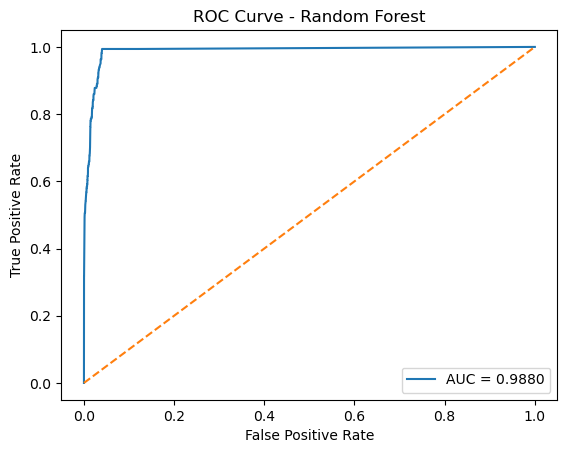

In [26]:
# ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

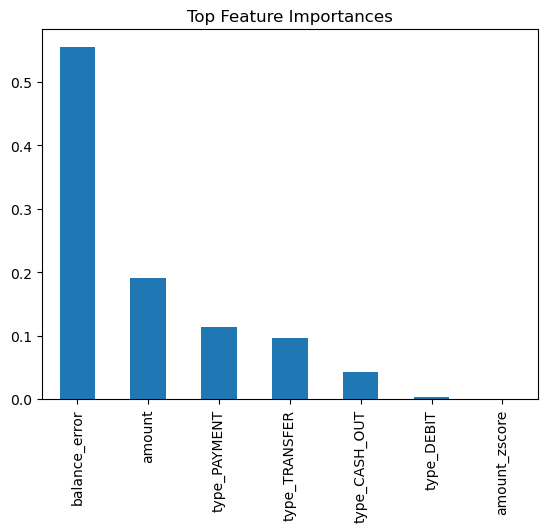

balance_error    0.554817
amount           0.190518
type_PAYMENT     0.113151
type_TRANSFER    0.096810
type_CASH_OUT    0.042020
type_DEBIT       0.002661
amount_zscore    0.000023
dtype: float64

In [27]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure()
importances.head(10).plot(kind='bar')
plt.title("Top Feature Importances")
plt.show()

importances.head(10)

## Model Interpretation

The introduction of engineered features improved the model’s ability to distinguish fraudulent transactions.

Key drivers of fraud detection include:
- Relative transaction size (amount_zscore)
- Balance inconsistencies (balance_error)
- Transaction type indicators

These features capture behavioural anomalies rather than relying solely on raw transaction values, aligning more closely with real-world fraud detection logic.